
# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


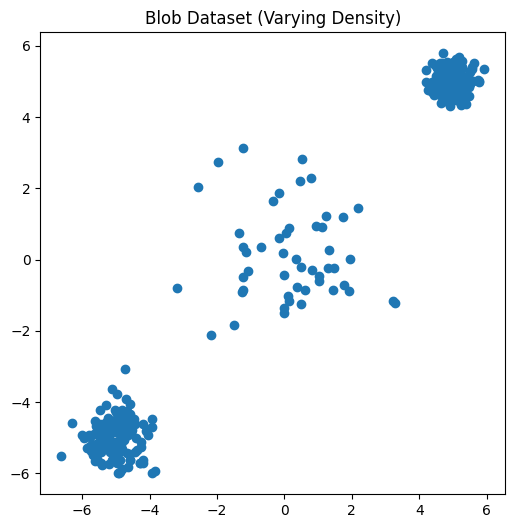

In [1]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [2]:
# TODO: Apply StandardScaler here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)


### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


In [5]:
from sklearn.cluster import DBSCAN

# TODO: Apply DBSCAN here
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X_blobs_scaled)



DBSCAN(eps=0.3)


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


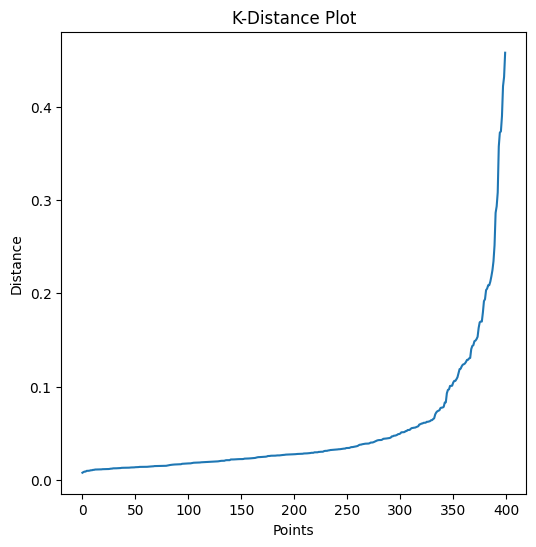

In [9]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
# TODO: Create k-distance plot
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_blobs_scaled)
distances, indices = neighbors_fit.kneighbors(X_blobs_scaled)

distances = np.sort(distances[:,4], axis=0)

plt.figure(figsize=(6,6))
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


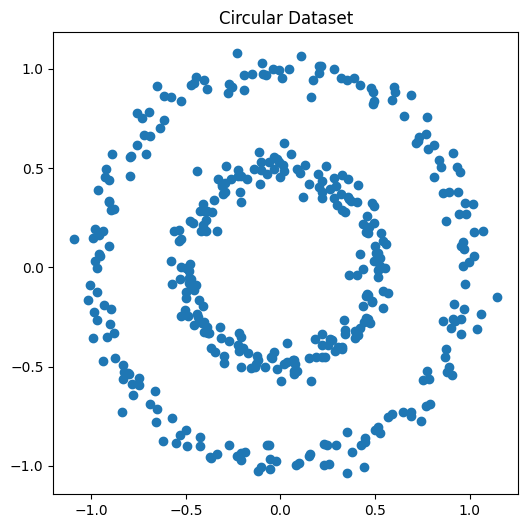

In [10]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


In [21]:
# TODO: Apply scaling and DBSCAN here
#Scaler
scaler = StandardScaler()
X_circles_scaled = scaler.fit_transform(X_circles)

#DBSCAN
dbscan = DBSCAN(eps=0.15, min_samples=3)
dbscan.fit(X_circles_scaled)

DBSCAN(eps=0.15, min_samples=3)


## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


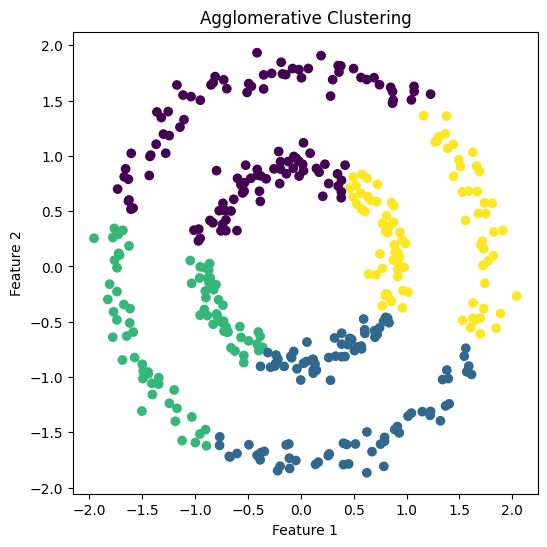

In [24]:
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering here
hc = AgglomerativeClustering(n_clusters=4, linkage='complete')
hc_labels= hc.fit(X_circles_scaled)


#Plot
plt.figure(figsize=(6,6))
plt.scatter(X_circles_scaled[:,0], X_circles_scaled[:,1], c=hc_labels.labels_)
plt.title("Agglomerative Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


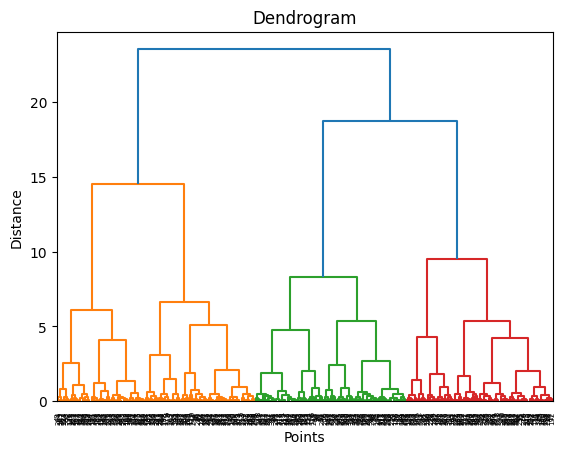

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here
linkage_matrix = linkage(X_circles_scaled, method='ward')

dendrogram(linkage_matrix)
plt.title("Dendrogram")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()


## Reflection Questions

1. Which dataset suits DBSCAN better?
2. How does eps affect noise?
3. Which linkage feels most intuitive?
4. When would you prefer hierarchical clustering?
